In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [42]:
path = '/content/drive/MyDrive/sorted_list/'

orders = pd.read_csv(path + 'olist_orders_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
translations = pd.read_csv(path + 'product_category_name_translation.csv')

print("All files loaded successfully!")
print(f"Orders: {orders.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Customers: {customers.shape}")
print(f"Products: {products.shape}")
print(f"Translations: {translations.shape}")

All files loaded successfully!
Orders: (99441, 8)
Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Translations: (71, 2)


In [43]:
# Fix reviews first - take average score per order
reviews_clean = reviews.groupby('order_id')['review_score'].mean().reset_index()

# Join orders with customers
master = pd.merge(orders, customers, on='customer_id', how='left')

# Join with reviews
master = pd.merge(master, reviews_clean, on='order_id', how='left')

print("Master table shape:", master.shape)
print(master.head(3))

Master table shape: (99441, 13)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date                customer_unique_id  \
0           2017-10-18 00:00:00  7c396fd4830fd04220f754e42b4e5bff   
1           2018-08-13 

In [44]:
# Convert date columns to datetime
master['order_delivered_customer_date'] = pd.to_datetime(
    master['order_delivered_customer_date'])
master['order_estimated_delivery_date'] = pd.to_datetime(
    master['order_estimated_delivery_date'])

# Calculate days difference
master['days_difference'] = (
    master['order_estimated_delivery_date'] -
    master['order_delivered_customer_date']
).dt.days

# Filter only delivered orders
master_delivered = master[
    master['order_status'] == 'delivered'
].copy()

# Remove missing delivery dates
master_delivered = master_delivered.dropna(
    subset=['order_delivered_customer_date',
            'order_estimated_delivery_date']
)

# Classify delivery status
def classify_delivery(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

master_delivered['delivery_status'] = master_delivered[
    'days_difference'].apply(classify_delivery)

print(master_delivered['delivery_status'].value_counts())
print(f"\nTotal delivered orders: {len(master_delivered)}")

delivery_status
On Time       88644
Super Late     4211
Late           3615
Name: count, dtype: int64

Total delivered orders: 96470


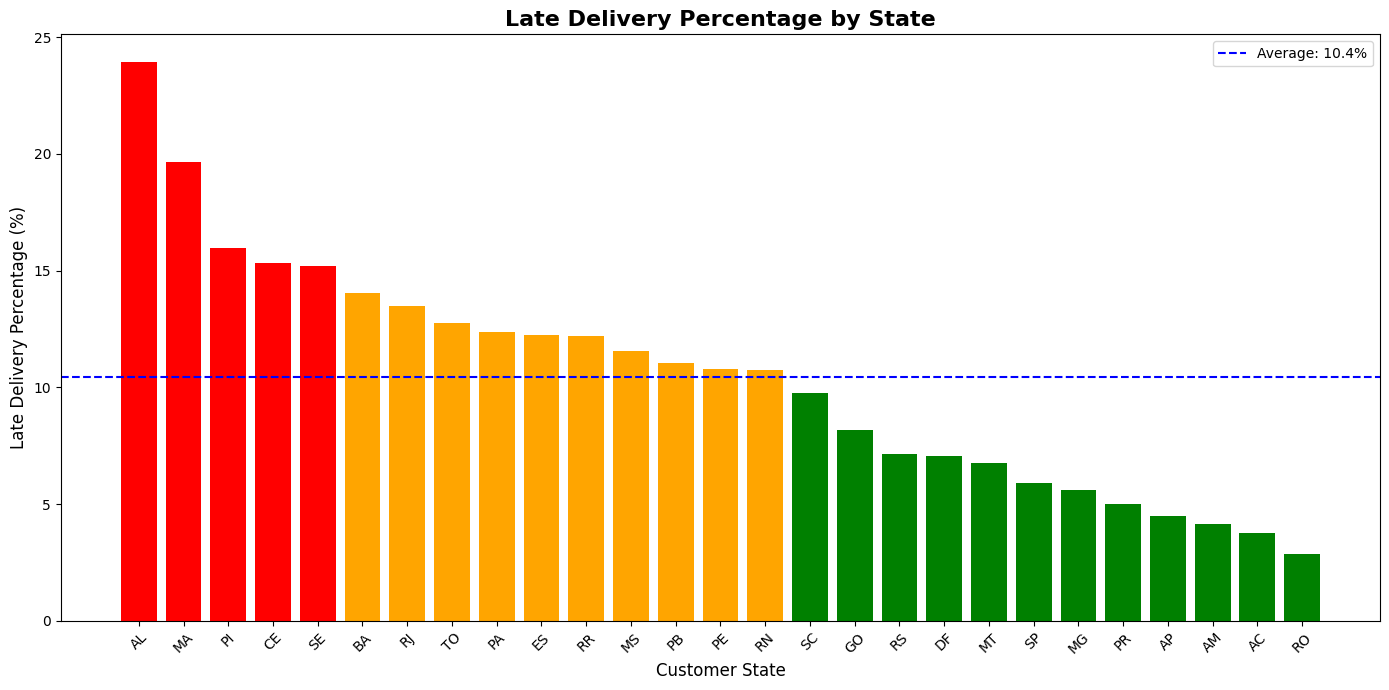

Average late delivery rate: 10.44%


In [45]:
# Calculate late delivery percentage per state
state_analysis = master_delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x != 'On Time').sum())
).reset_index()

# Calculate percentage
state_analysis['late_percentage'] = (
    state_analysis['late_orders'] /
    state_analysis['total_orders'] * 100
).round(2)

# Sort by worst states
state_analysis = state_analysis.sort_values(
    'late_percentage', ascending=False)

# Plot the chart
plt.figure(figsize=(14, 7))

colors = ['red' if x > 15 else 'orange' if x > 10
          else 'green' for x in state_analysis['late_percentage']]

plt.bar(state_analysis['customer_state'],
        state_analysis['late_percentage'],
        color=colors)

plt.title('Late Delivery Percentage by State',
          fontsize=16, fontweight='bold')
plt.xlabel('Customer State', fontsize=12)
plt.ylabel('Late Delivery Percentage (%)', fontsize=12)
plt.xticks(rotation=45)

avg_late = state_analysis['late_percentage'].mean()
plt.axhline(y=avg_late, color='blue',
            linestyle='--',
            label=f'Average: {avg_late:.1f}%')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/late_deliveries_by_state.png', dpi=150)
plt.show()

print(f"Average late delivery rate: {avg_late:.2f}%")

In [46]:
# Average review score by delivery status
sentiment = master_delivered.groupby(
    'delivery_status')['review_score'].agg(
    average_score='mean',
    total_orders='count'
).reset_index()

print(sentiment)
print()

# Correlation between delivery speed and reviews
correlation = master_delivered['days_difference'].corr(
    master_delivered['review_score']
)
print(f"Correlation between delivery speed and review score: {correlation:.3f}")

  delivery_status  average_score  total_orders
0            Late       3.461183          3568
1         On Time       4.294292         88163
2      Super Late       1.786587          4093

Correlation between delivery speed and review score: 0.267


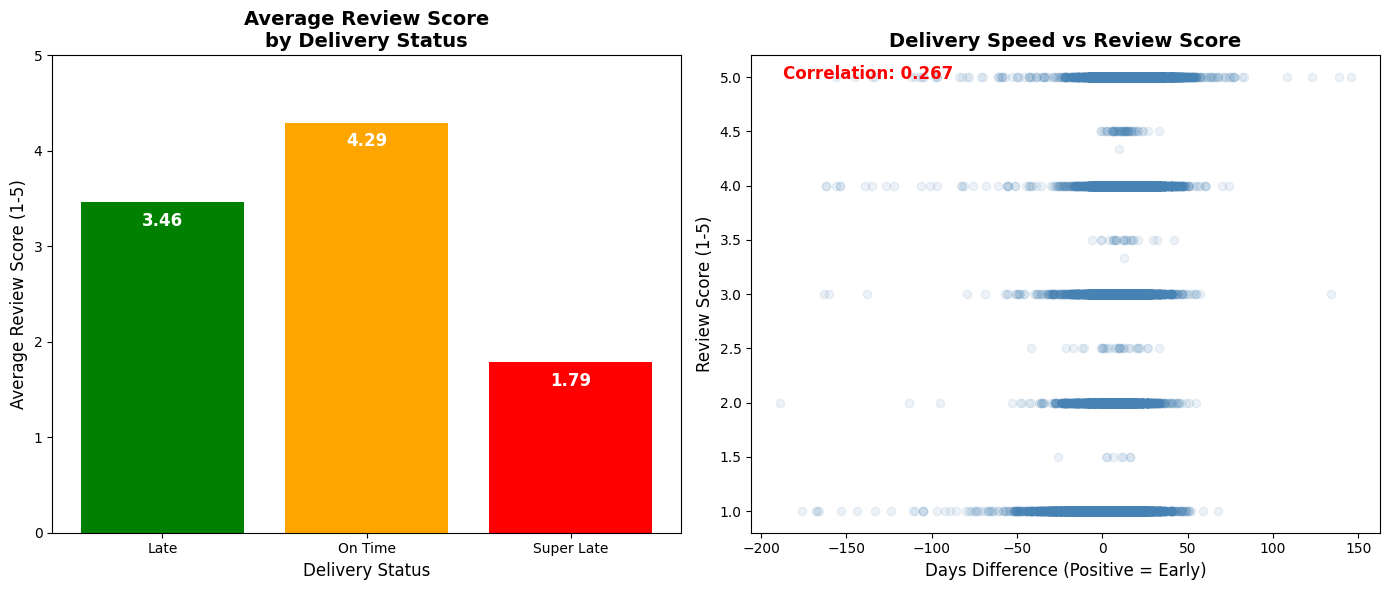

In [47]:
# Create sentiment correlation chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Average review score by delivery status
colors = ['green', 'orange', 'red']
bars = ax1.bar(sentiment['delivery_status'],
               sentiment['average_score'],
               color=colors)

# Add value labels on bars
for bar, val in zip(bars, sentiment['average_score']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.1,
             f'{val:.2f}',
             ha='center', va='top',
             color='white', fontweight='bold',
             fontsize=12)

ax1.set_title('Average Review Score\nby Delivery Status',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Delivery Status', fontsize=12)
ax1.set_ylabel('Average Review Score (1-5)', fontsize=12)
ax1.set_ylim(0, 5)

# Chart 2 — Scatter plot of days difference vs review score
ax2.scatter(master_delivered['days_difference'],
            master_delivered['review_score'],
            alpha=0.1, color='steelblue')

ax2.set_title('Delivery Speed vs Review Score',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Days Difference (Positive = Early)', fontsize=12)
ax2.set_ylabel('Review Score (1-5)', fontsize=12)

# Add correlation text
ax2.text(0.05, 0.95,
         f'Correlation: {correlation:.3f}',
         transform=ax2.transAxes,
         fontsize=12, fontweight='bold',
         color='red')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sentiment_correlation.png', dpi=150)
plt.show()

In [48]:
# Join products with translations
products_translated = pd.merge(
    products,
    translations,
    on='product_category_name',
    how='left'
)

# Check result
print(products_translated[['product_category_name',
      'product_category_name_english']].head(10))
print()
print("Shape:", products_translated.shape)

   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares
5  instrumentos_musicais           musical_instruments
6             cool_stuff                    cool_stuff
7       moveis_decoracao               furniture_decor
8       eletrodomesticos               home_appliances
9             brinquedos                          toys

Shape: (32951, 10)


In [49]:
# We need to bring order_id into products
# First load the order_items file
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')

print("Order items shape:", order_items.shape)
print(order_items.head(3))

Order items shape: (112650, 7)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35   58.9          13.29  
1  2017-05-03 11:05:13  239.9          19.93  
2  2018-01-18 14:48:30  199.0          17.87  


In [50]:
# Load order items
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')

print("Order items shape:", order_items.shape)
print(order_items.head(3))

Order items shape: (112650, 7)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35   58.9          13.29  
1  2017-05-03 11:05:13  239.9          19.93  
2  2018-01-18 14:48:30  199.0          17.87  


In [51]:
# Join order_items with products_translated
items_with_products = pd.merge(
    order_items[['order_id', 'product_id']],
    products_translated[['product_id',
                         'product_category_name_english']],
    on='product_id',
    how='left'
)

# Join with master_delivered to get delivery status
items_with_delivery = pd.merge(
    items_with_products,
    master_delivered[['order_id', 'delivery_status']],
    on='order_id',
    how='inner'
)

print("Shape:", items_with_delivery.shape)
print(items_with_delivery.head(5))

Shape: (110189, 4)
                           order_id                        product_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  4244733e06e7ecb4970a6e2683c13e61   
1  00018f77f2f0320c557190d7a144bdd3  e5f2d52b802189ee658865ca93d83a8f   
2  000229ec398224ef6ca0657da4fc703e  c777355d18b72b67abbeef9df44fd0fd   
3  00024acbcdf0a6daa1e931b038114c75  7634da152a4610f1595efa32f14722fc   
4  00042b26cf59d7ce69dfabb4e55b4fd9  ac6c3623068f30de03045865e4e10089   

  product_category_name_english delivery_status  
0                    cool_stuff         On Time  
1                      pet_shop         On Time  
2               furniture_decor         On Time  
3                     perfumery         On Time  
4                  garden_tools         On Time  


In [52]:
# Calculate late delivery % per product category
category_analysis = items_with_delivery.groupby(
    'product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status',
                 lambda x: (x != 'On Time').sum())
).reset_index()

# Calculate percentage
category_analysis['late_percentage'] = (
    category_analysis['late_orders'] /
    category_analysis['total_orders'] * 100
).round(2)

# Filter categories with at least 50 orders
# to avoid misleading small sample sizes
category_analysis = category_analysis[
    category_analysis['total_orders'] >= 50
]

# Sort by worst performing
category_analysis = category_analysis.sort_values(
    'late_percentage', ascending=False)

print("Top 10 worst categories:")
print(category_analysis.head(10))
print()
print("Top 10 best categories:")
print(category_analysis.tail(10))

Top 10 worst categories:
   product_category_name_english  total_orders  late_orders  late_percentage
4                          audio           362           46            12.71
33       fashion_underwear_beach           127           16            12.60
12            christmas_supplies           150           18            12.00
10               books_technical           263           29            11.03
47                  home_confort           429           44            10.26
18     construction_tools_lights           301           30             9.97
36                          food           499           49             9.82
26                   electronics          2729          266             9.75
43                 health_beauty          9465          857             9.05
57              office_furniture          1668          149             8.93

Top 10 best categories:
              product_category_name_english  total_orders  late_orders  \
62                   signalin

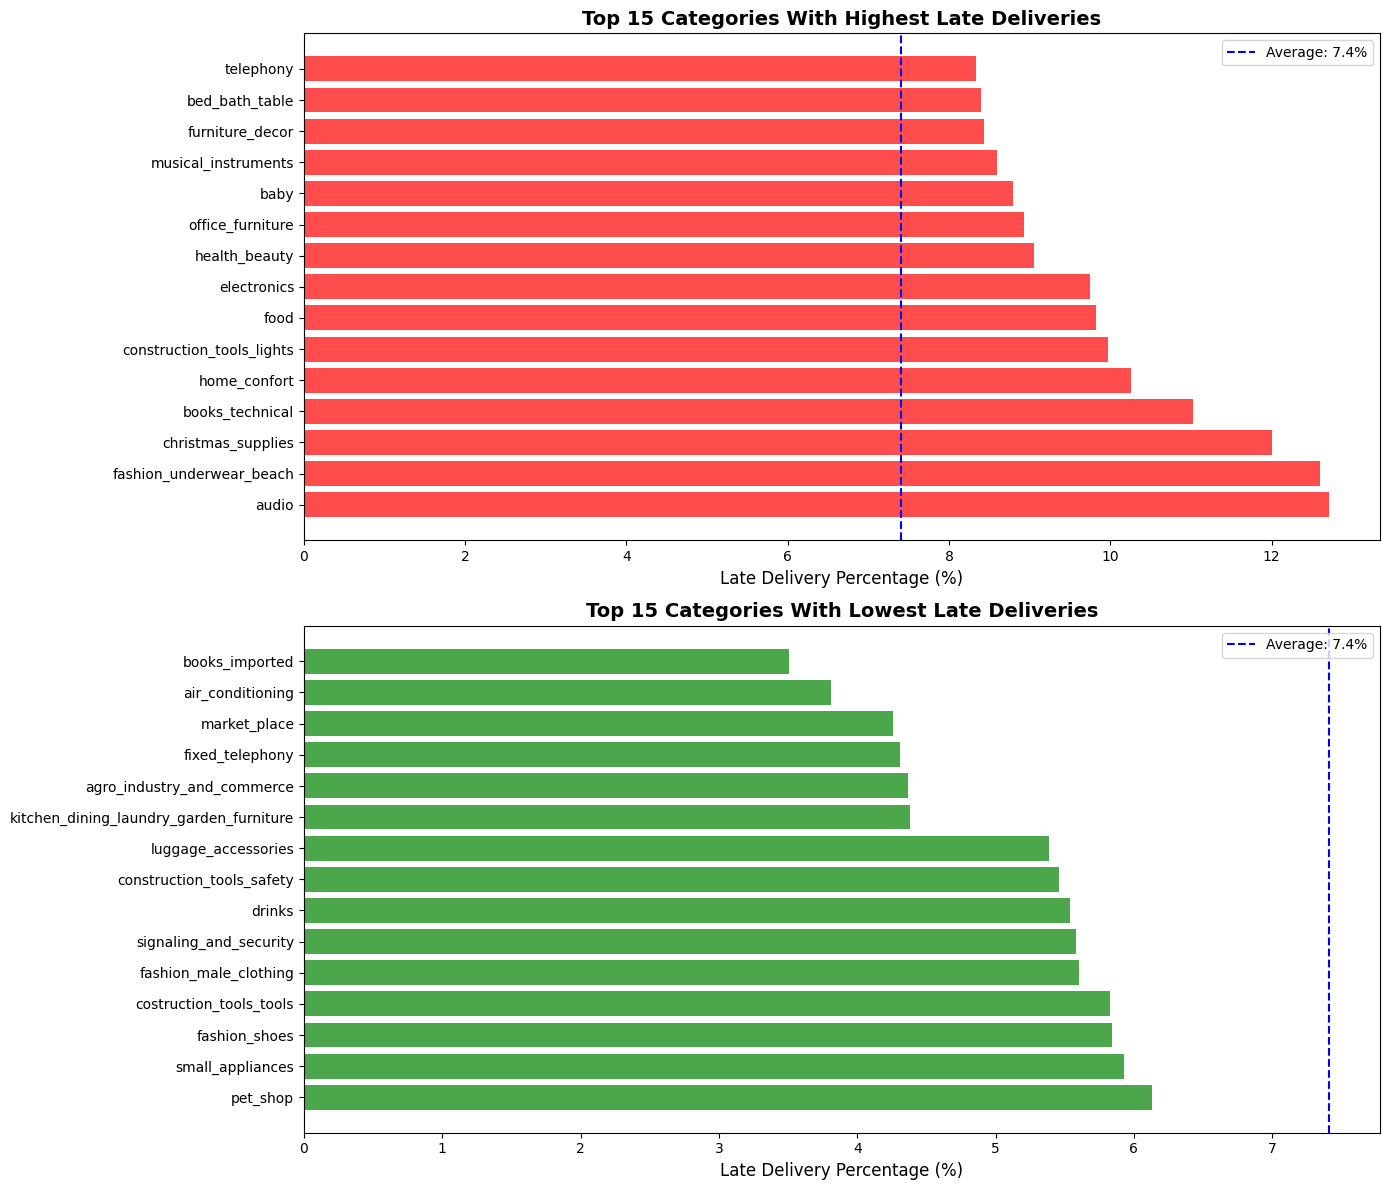

In [53]:
# Plot top 15 worst and best categories
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Top 15 worst categories
worst = category_analysis.head(15)
ax1.barh(worst['product_category_name_english'],
         worst['late_percentage'],
         color='red', alpha=0.7)
ax1.set_title('Top 15 Categories With Highest Late Deliveries',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Late Delivery Percentage (%)', fontsize=12)
ax1.axvline(x=category_analysis['late_percentage'].mean(),
            color='blue', linestyle='--',
            label=f'Average: {category_analysis["late_percentage"].mean():.1f}%')
ax1.legend()

# Top 15 best categories
best = category_analysis.tail(15)
ax2.barh(best['product_category_name_english'],
         best['late_percentage'],
         color='green', alpha=0.7)
ax2.set_title('Top 15 Categories With Lowest Late Deliveries',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Late Delivery Percentage (%)', fontsize=12)
ax2.axvline(x=category_analysis['late_percentage'].mean(),
            color='blue', linestyle='--',
            label=f'Average: {category_analysis["late_percentage"].mean():.1f}%')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/category_analysis.png', dpi=150)
plt.show()

In [54]:
# Extract month and year from purchase date
master_delivered['order_purchase_timestamp'] = pd.to_datetime(
    master_delivered['order_purchase_timestamp'])

master_delivered['year_month'] = master_delivered[
    'order_purchase_timestamp'].dt.to_period('M')

# Calculate late delivery % per month
monthly_analysis = master_delivered.groupby('year_month').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status',
                 lambda x: (x != 'On Time').sum())
).reset_index()

monthly_analysis['late_percentage'] = (
    monthly_analysis['late_orders'] /
    monthly_analysis['total_orders'] * 100
).round(2)

# Convert period to string for plotting
monthly_analysis['year_month'] = monthly_analysis[
    'year_month'].astype(str)

print(monthly_analysis)

   year_month  total_orders  late_orders  late_percentage
0     2016-09             1            1           100.00
1     2016-10           265            3             1.13
2     2016-12             1            0             0.00
3     2017-01           750           23             3.07
4     2017-02          1653           53             3.21
5     2017-03          2546          142             5.58
6     2017-04          2303          181             7.86
7     2017-05          3545          128             3.61
8     2017-06          3135          121             3.86
9     2017-07          3872          133             3.43
10    2017-08          4193          139             3.32
11    2017-09          4150          216             5.20
12    2017-10          4478          237             5.29
13    2017-11          7288         1043            14.31
14    2017-12          5513          462             8.38
15    2018-01          7069          464             6.56
16    2018-02 

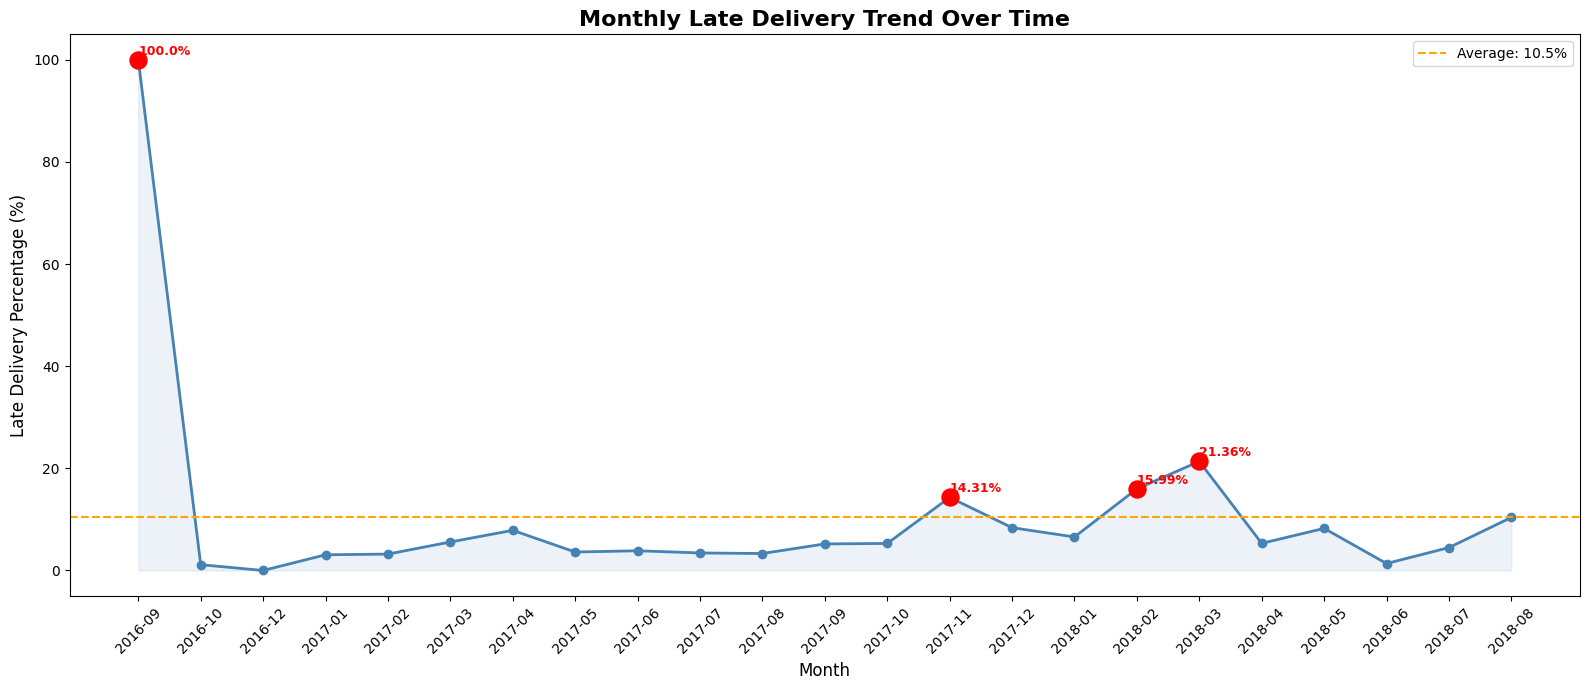


Worst month: 2016-09 at 100.00%
Best month: 2016-12 at 0.00%


In [55]:
# Plot monthly trend
plt.figure(figsize=(16, 7))

# Plot the line
plt.plot(monthly_analysis['year_month'],
         monthly_analysis['late_percentage'],
         color='steelblue', linewidth=2,
         marker='o', markersize=6)

# Fill area under line
plt.fill_between(range(len(monthly_analysis)),
                 monthly_analysis['late_percentage'],
                 alpha=0.1, color='steelblue')

# Highlight worst months in red
worst_months = monthly_analysis[
    monthly_analysis['late_percentage'] > 14]
for _, row in worst_months.iterrows():
    idx = monthly_analysis[
        monthly_analysis['year_month'] ==
        row['year_month']].index[0]
    plt.scatter(idx, row['late_percentage'],
                color='red', s=150, zorder=5)
    plt.annotate(f"{row['late_percentage']}%",
                xy=(idx, row['late_percentage']),
                xytext=(idx, row['late_percentage'] + 1),
                fontsize=9, color='red',
                fontweight='bold')

# Add average line
avg = monthly_analysis['late_percentage'].mean()
plt.axhline(y=avg, color='orange',
            linestyle='--',
            label=f'Average: {avg:.1f}%')

# Labels and formatting
plt.title('Monthly Late Delivery Trend Over Time',
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Late Delivery Percentage (%)', fontsize=12)
plt.xticks(range(len(monthly_analysis)),
           monthly_analysis['year_month'],
           rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/monthly_trend.png',
            dpi=150)
plt.show()

print(f"\nWorst month: {monthly_analysis.loc[monthly_analysis['late_percentage'].idxmax(), 'year_month']} "
      f"at {monthly_analysis['late_percentage'].max():.2f}%")
print(f"Best month: {monthly_analysis.loc[monthly_analysis['late_percentage'].idxmin(), 'year_month']} "
      f"at {monthly_analysis['late_percentage'].min():.2f}%")

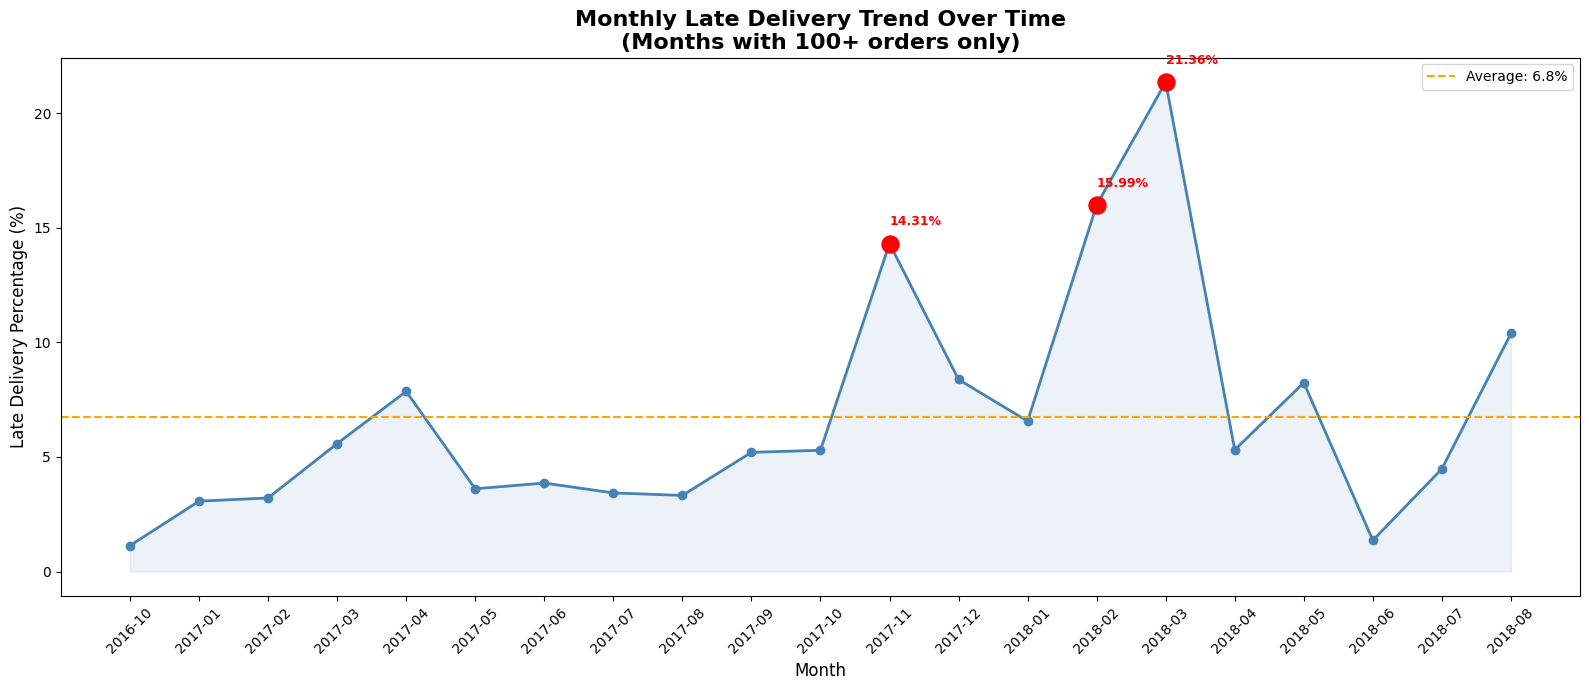

Worst month: 2018-03 at 21.36%
Best month: 2016-10 at 1.13%


In [56]:
# Filter out months with less than 100 orders
# to avoid misleading small sample sizes
monthly_analysis_filtered = monthly_analysis[
    monthly_analysis['total_orders'] >= 100
].copy()

# Replot with filtered data
plt.figure(figsize=(16, 7))

plt.plot(monthly_analysis_filtered['year_month'],
         monthly_analysis_filtered['late_percentage'],
         color='steelblue', linewidth=2,
         marker='o', markersize=6)

plt.fill_between(range(len(monthly_analysis_filtered)),
                 monthly_analysis_filtered['late_percentage'],
                 alpha=0.1, color='steelblue')

# Highlight worst months
worst_months = monthly_analysis_filtered[
    monthly_analysis_filtered['late_percentage'] > 14]
for _, row in worst_months.iterrows():
    idx = list(monthly_analysis_filtered[
        'year_month']).index(row['year_month'])
    plt.scatter(idx, row['late_percentage'],
                color='red', s=150, zorder=5)
    plt.annotate(f"{row['late_percentage']}%",
                xy=(idx, row['late_percentage']),
                xytext=(idx, row['late_percentage'] + 0.8),
                fontsize=9, color='red',
                fontweight='bold')

# Average line
avg = monthly_analysis_filtered['late_percentage'].mean()
plt.axhline(y=avg, color='orange',
            linestyle='--',
            label=f'Average: {avg:.1f}%')

plt.title('Monthly Late Delivery Trend Over Time\n(Months with 100+ orders only)',
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Late Delivery Percentage (%)', fontsize=12)
plt.xticks(range(len(monthly_analysis_filtered)),
           monthly_analysis_filtered['year_month'],
           rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/monthly_trend.png',
            dpi=150)
plt.show()

print(f"Worst month: {monthly_analysis_filtered.loc[monthly_analysis_filtered['late_percentage'].idxmax(), 'year_month']} "
      f"at {monthly_analysis_filtered['late_percentage'].max():.2f}%")
print(f"Best month: {monthly_analysis_filtered.loc[monthly_analysis_filtered['late_percentage'].idxmin(), 'year_month']} "
      f"at {monthly_analysis_filtered['late_percentage'].min():.2f}%")